#### Importing Required Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import os
import torch

# Ignoring warnings
import warnings as war
war.filterwarnings('ignore')

#### Defining Device for Training Model

In [3]:
# Device agnostic code
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Chosen Processing Unit : {device}")

Chosen Processing Unit : cuda


#### Downloading Data from kagglehub

In [ ]:
# let's download data from kagglehub and store it in our system
import kagglehub as KagHub
path = KagHub.dataset_download("murtozalikhon/brain-tumor-multimodal-image-ct-and-mri")
print(f"Path to dataset files: {path}") 

In [32]:
# Define dataset path 
dataset_path = "C:/Users/harde/.cache/kagglehub/datasets/murtozalikhon/brain-tumor-multimodal-image-ct-and-mri/versions/1/Dataset/Brain Tumor MRI images"
categories = ['Healthy', 'Tumor']

#### Defining Data Transformation/Modelling Functions

In [53]:
# Let's write a function to load and display sample images
def display_sample_images(dataset_path,categories, sample_count = 5):
    fig,axes = plt.subplots(len(categories),sample_count,figsize = (15,5))
    for i, category in enumerate(categories):
        category_path = os.path.join(dataset_path,category)
        images = os.listdir(category_path)[:sample_count]

        # Entered into one directory and now let's start pulling images
        for j, img_name in enumerate(images):
            img_path = os.path.join(category_path,img_name)
            img = Image.open(img_path)
            axes[i, j].imshow(img, cmap="gray" if img.mode == "L" else None)
            axes[i, j].axis('off')
            axes[i, j].set_title(f"{category}")
        plt.tight_layout()
    plt.show()

# Function to check image shapes and sizes
def explore_image_shapes(dataset_path,categories):
    shape_counter = Counter()
    for category in categories:
        category_path = os.path.join(dataset_path,category)
        for img_name in os.listdir(category_path):
            img_path = os.path.join(category_path,img_name)
            try:
                img = Image.open(img_path)
                shape_counter[img.size] += 1 # Shape as (width,height)
            except Exception as e:
                print(f"Error loading {img_name} : {e}")
    return shape_counter

# Function to calculate pixel stats
def calculate_pixel_stats(dataset_path,categories):
    all_pixels = []
    for category in categories:
        category_path = os.path.join(dataset_path,category)
        for img_name in os.listdir(category_path):
            img_path = os.path.join(category_path,img_name)
            try:
                img = Image.open(img_path)
                img_array = np.array(img)
                all_pixels.append(img_array)
            except Exception as e:
                print(f"Error loading {img_name} : {e}")
                
    all_pixels = np.concatenate([img.flatten() for img in all_pixels])
    mean = np.mean(all_pixels)
    std = np.std(all_pixels)
    return mean,std

# Function to count class distribution
def count_class_distribution(dataset_path,categories):
    class_counts = {}
    for category in categories:
        category_path = os.path.join(dataset_path,category)
        class_counts[category] = len(os.listdir(category_path))
    return class_counts



Dataset Samples: 



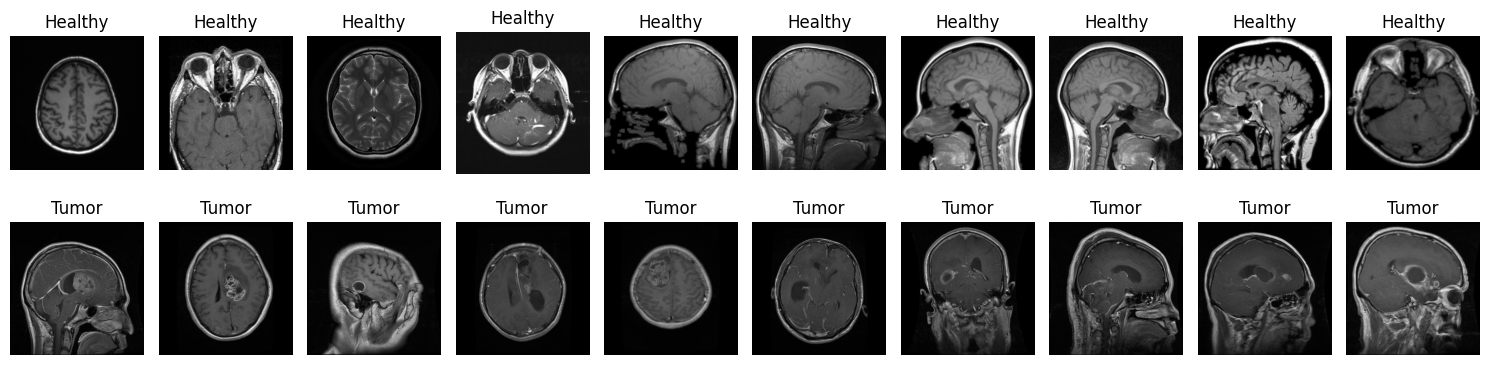

In [38]:
# Let's call the method to see sampled images from our dataset from all categories
print("Dataset Samples: \n")
display_sample_images(dataset_path,categories,sample_count = 10)

In [37]:
print("Dataset Image Shapes: \n")
explore_image_shapes(dataset_path,categories)

Dataset Image Shapes: 



Counter({(512, 512): 2478,
         (256, 256): 570,
         (225, 225): 188,
         (630, 630): 124,
         (640, 640): 100,
         (236, 236): 86,
         (224, 224): 77,
         (442, 442): 56,
         (300, 168): 43,
         (428, 417): 36,
         (468, 444): 27,
         (200, 252): 25,
         (201, 250): 23,
         (227, 222): 22,
         (201, 251): 21,
         (206, 244): 20,
         (504, 540): 19,
         (550, 664): 18,
         (150, 198): 18,
         (350, 350): 18,
         (359, 449): 17,
         (215, 234): 16,
         (173, 201): 16,
         (680, 680): 15,
         (220, 275): 14,
         (642, 361): 14,
         (393, 400): 12,
         (236, 269): 12,
         (442, 454): 12,
         (400, 442): 11,
         (228, 221): 10,
         (218, 231): 10,
         (236, 260): 10,
         (232, 217): 10,
         (554, 554): 10,
         (455, 500): 10,
         (236, 251): 9,
         (235, 227): 9,
         (236, 263): 9,
         (234, 218): 9

In [54]:
# Calling stored method to get mean & standard deviation stored in two variables
Dataset_mean, Dataset_std = calculate_pixel_stats(dataset_path,categories)
print(f"Dataset Pixels Stats: \n Mean: {Dataset_mean}, Standard Deviation: {Dataset_std}")

Dataset Pixels Stats: 
 Mean: 46.87433304142097, Standard Deviation: 50.18397011042206


In [36]:
print("Dataset Class Distribution: \n")
count_class_distribution(dataset_path,categories)


 Dataset Class Distribution: 



{'Healthy': 2000, 'Tumor': 3000}

1. Image Shapes
##### Why Check Image Shapes?
- Uniformity in Shape: Most models require all images to have the same dimensions. If your dataset contains images of varying shapes (e.g., different resolutions), you'll need to resize or crop them.
- Aspect Ratio Awareness: If resizing is required, knowing the original aspect ratios helps prevent distortions during preprocessing.
- Optimization: Large image sizes can slow down training. Knowing the image sizes helps determine an optimal resolution for resizing.

2. Pixel Statistics (Mean and Standard Deviation)
##### Why Check Pixel Stats?
- Normalization: Pixel intensity values in images can range from 0-255 (or 0-1 after scaling). Normalizing the dataset by subtracting the mean and dividing by the standard deviation helps improve the training process. This ensures the model trains faster and reduces the chance of gradient instability.
- Variance Awareness: High variance or extreme values in pixel intensities can indicate anomalies, like very bright or dark images, that may require preprocessing.
- Color vs Grayscale: Exploring pixel values can also confirm whether images are grayscale or RGB, which affects model architecture.

3. Practical Use Cases
###### Here’s how these steps help:
- Preprocessing: Decide whether to resize, crop, normalize, or augment data.
- Data Augmentation: If images have consistent shapes and intensities, augmentation (e.g., rotations, flips, brightness adjustments) can be applied confidently to improve generalization.
- Class Imbalance: Detecting if one class (e.g., "tumor") has far fewer images than the other can guide sampling strategies during training.

#### Defining Dataset Transformation 

If your dataset is grayscale:

Use a single mean and std value which are found above.
If your dataset is RGB:

Compute mean and std for each channel (R, G, B) separately, as each channel may have different statistics.

Example mean and std for RGB (if calculated separately)
mean = [0.485, 0.456, 0.406]  # Replace with your dataset's values
std = [0.229, 0.224, 0.225]   # Replace with your dataset's values


In [64]:
from torchvision import transforms

dataset_mean = round(Dataset_mean / 255.0,2)
dataset_std = round(Dataset_std / 255.0,2)

# Define transformations
transform = transforms.Compose([
    transforms.Resize((224,224)), # Resize all images to 224X224
    # transforms.RandomHorizontalFlip(), # Random horizontal flip (for data augmentation, if required)
    transforms.ToTensor(),  # Convert images to tensors
    transforms.Normalize(mean=dataset_mean, std=dataset_std) # Normalize pixel values 
])

# I have calculated here mean,std as single for RGB(3 colors) but it could be calculated separatly for three of them   

#### Data Preparation: Train/Test Split

In [65]:
from torchvision import datasets, transforms # For data transformation into desired size 
from torch.utils.data import DataLoader, random_split # For loading data in desired train/test split

# Load Dataset
dataset = datasets.ImageFolder(root = dataset_path, transform = transform)

# Split Dataset 
train_size = int(0.8 * len(dataset))  # 80% data for training 
test_size = len(dataset) - train_size  # 20% data for testing 
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = True)

print(f"Training Samples: {len(train_dataset)}")
print(f"Testing Samples: {len(test_dataset)}")

Training Samples: 4000
Testing Samples: 1000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.90000004..3.7470589].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.90000004..4.0607843].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.90000004..4.0411763].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.90000004..4.0607843].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.90000004..4.1].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.90000004..4.1].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.90000004..3.

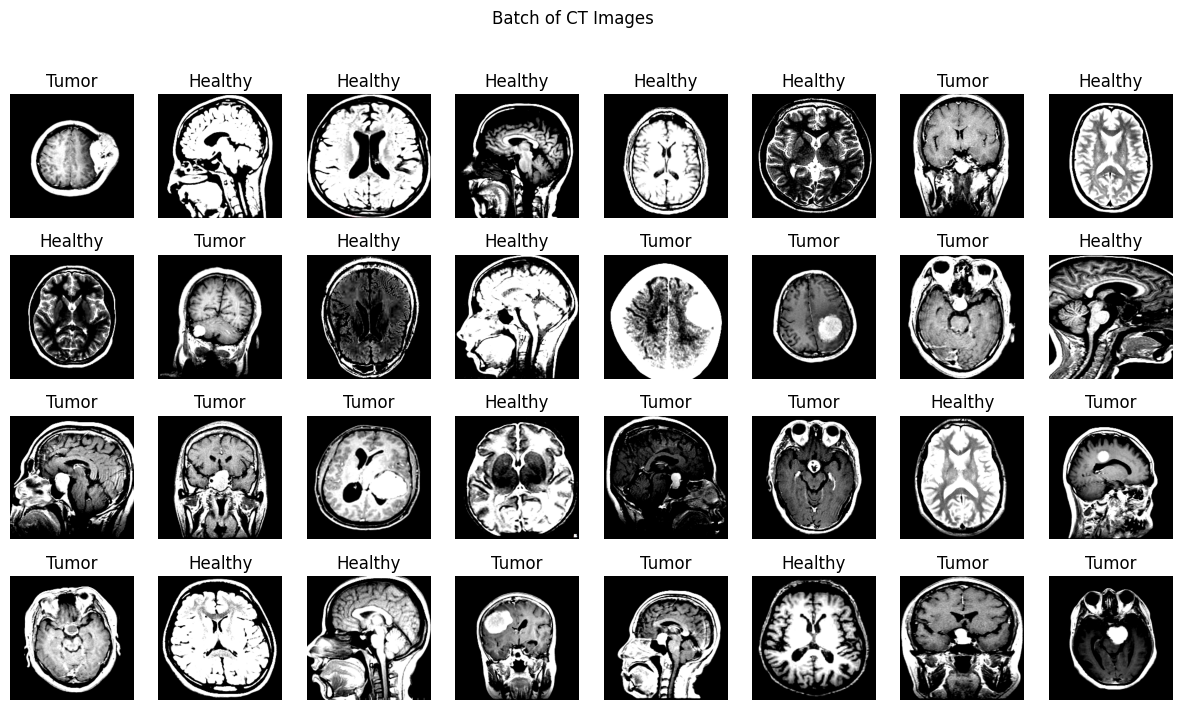

In [69]:
# Function for showing batches 
def show_MRI_batch(dataloader, title="Batch of CT Images"):
    images, labels = next(iter(dataloader))
    fig, axes = plt.subplots(4, 8, figsize=(15, 8))
    fig.suptitle(title)
    
    for i, ax in enumerate(axes.flatten()):
        if i < len(images):
            img = images[i].permute(1, 2, 0)  # Convert tensor image for plotting
            ax.imshow(img)
            ax.set_title(dataset.classes[labels[i]])
            ax.axis('off')
    plt.show()

# Calling function to see a batch from training data
show_MRI_batch(train_loader)

#### Defining CNN Architecture

##### Designing a CNN involves determining:

###### Number of Layers:
Balancing between underfitting (too few layers) and overfitting (too many layers).

###### Layer Types:
- Convolutional Layers: Extract spatial features.
- Pooling Layers: Reduce dimensions while retaining important features.
- Fully Connected (Dense) Layers: Map high-level features to output    classes.
###### Filter Sizes & Count:
Start small (e.g., 3x3 filters).
Gradually increase filter count to capture more complex features.

##### Guidelines for Designing CNN
###### Start Simple:
Begin with 2-3 convolutional layers followed by pooling layers.
Gradually increase the complexity if results are not satisfactory.

###### Heuristic for Filters:
Start with a small number of filters (e.g., 32 or 64).
Double the number of filters after each pooling layer.

###### ReLU Activation:
Apply ReLU after every convolution to introduce non-linearity.

###### Dropout Regularization:
Use dropout (e.g., 0.5) after fully connected layers to prevent overfitting.

##### Overall we should:
##### Start Small:
- Begin with a basic architecture (e.g., 2-3 convolutional layers).
- Check performance (e.g., accuracy, loss).
##### Iteratively Tune:
- Add layers (convolutional, pooling, or fully connected) to improve results.
- Experiment with filter sizes, strides, and number of filters.
##### Pre-Trained Models:
- Use pre-trained models like ResNet, VGG, or EfficientNet (via transfer learning) to save time and leverage their proven architectures.

##### Formula for finding "Pooling Layer":  Height, Width
- Output Height = ((H + 2*P - K) / S) + 1)
- Output Width = ((W + 2*P - K) / S) + 1)

Where:
- H,W: Input height and width.
- K: Kernel size (pooling window size, e.g., 
- S: Stride (step size of the pooling operation).
- P: Padding (if any, typically 0 for pooling layers).


In [89]:
# let's define a class for our model to train
import torch.nn as nn   # "nn" stands for "neural network" and refers to the torch.nn module, which provides the core building blocks for creating and training neural networks.

class MRI_ScanTumorClassifierCNN(nn.Module):
    def __init__(self, in_channels, num_classes, dropout = 0.5):
        super().__init__()

        # Define the convolutional and pooling layers as a sequence
        self.features = nn.Sequential(
            nn.Conv2d(in_channels = in_channels, out_channels = 32, kernel_size = 3, stride = 1, padding = 1),  # Conv Layer 1, Size: [32,224,224]
            nn.ReLU(),                                                                                          # Activation, Size: [32,224,224]
            nn.MaxPool2d(kernel_size = 2, stride = 2),                                                          # Pooling Layer 1, Size: [32, 112, 112]

            nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, stride = 1, padding = 1), # Conv Layer 2, Size: [64,112,112]
            nn.ReLU(),                                                                                # Activation, Size: [64,112,112]
            nn.MaxPool2d(kernel_size = 2, stride = 2),                                                # Pooling Layer 2, Size: [64, 56,56]
        )

        # Fully Connected Layers (Classifier)
        self.classifier = nn.Sequential(
            nn.Flatten(),                                              # Flatten to (batch_size, Size: [64 * 56 * 56])
            nn.Linear(in_features = 64 * 56 * 56, out_features = 128), # Fully connected layer (reduce dimensionality), Size: [128]
            nn.ReLU(),                                                 # Activation, Size: [128]
            nn.Dropout(dropout),                                       # Dropout layer to prevent overfitting, Size: [128]
            nn.Linear(in_features = 128, out_features = num_classes)   # Fully connected final output layer, Size: [2] (num_classes)
        )

    def forward(self,input):
        # pass input dataset through feature extractor 
        input = self.features(input)
        # pass extracted input through classifier
        input = self.classifier(input)
        return input

# Instantiate the model 
model = MRI_ScanTumorClassifierCNN(in_channels =  3, num_classes = 2)  # in_channels = 1 for grayscale images, num_classes = 2 for number of classes to predict
print(model)

MRI_ScanTumorClassifierCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=200704, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


#### Training and Testing the Model

In [91]:
import torch.optim as optim 
from tqdm import tqdm

# Define loss and optimizer 
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

num_epochs = 10
all_labels = []
all_predictions = []

# Training loop, defining number of times our data will be used to update weights & train our model 
for epoch in range(num_epochs):
    # model training 
    model.train()  # put model in training mode
    running_loss = 0.0
    for inputs,labels in tqdm(train_loader):
        # Move data to GPU if available
        inputs, labels = inputs.to(device), labels.to(device)

        # Resetting the gradients from previous run 
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()  # Calculating gradients for all parameters
        optimizer.step()  # Updating newly calculated gradients in model

        running_loss += loss.item()  # Adding loss

    # model testing 
    model.eval()  # put model in testing mode
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader):
            inputs,labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)  # Shape: [inputs_size, num_classes]
            
            '''
            Returns two values:
            - Maximum values (we ignore this with _ since we don't need it).
            - Indices of the maximum values (these are the predicted class labels, stored in predicted).
            Example: If outputs is:
            tensor([[0.1, 2.5]]),  # Logits output for input 1
            Then:
            - torch.max(outputs, 1) → (tensor([2.5, 1.0]), tensor([1, 0]))  {maximum values, there indices}
            - predicted will be [1, 0], corresponding to the predicted class indices.
            '''
            _,predicted = torch.max(outputs,1)  # Taking out the maximum value of logits out of two output values for each image
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    print(f"Epoch [{epoch + 1}/{num_epochs}], Training Loss: {running_loss / len(train_loader):.4f}, Accuracy of model on validation set: {100 * correct / total:.2f}%")
    


100%|██████████████████████████████████████████████████████████████████████████████████| 32/32 [00:16<00:00,  1.88it/s]


Epoch [1/10], Loss: 0.7413, Accuracy of model on validation set: 89.20%


100%|██████████████████████████████████████████████████████████████████████████████████| 32/32 [00:14<00:00,  2.16it/s]


Epoch [2/10], Loss: 0.2576, Accuracy of model on validation set: 93.30%


100%|██████████████████████████████████████████████████████████████████████████████████| 32/32 [00:14<00:00,  2.20it/s]


...

Epoch [8/10], Loss: 0.0180, Accuracy of model on validation set: 96.30%


100%|██████████████████████████████████████████████████████████████████████████████████| 32/32 [00:13<00:00,  2.43it/s]


Epoch [9/10], Loss: 0.0212, Accuracy of model on validation set: 95.40%


100%|██████████████████████████████████████████████████████████████████████████████████| 32/32 [00:14<00:00,  2.18it/s]

Epoch [10/10], Loss: 0.0162, Accuracy of model on validation set: 97.00%


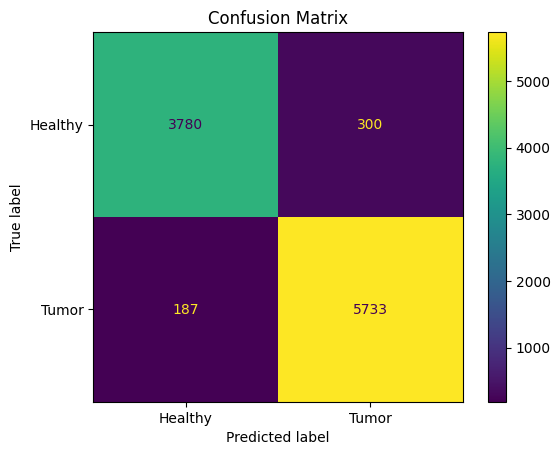

In [92]:
# Let's see the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_predictions)

display = ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = ["Healthy","Tumor"])
display.plot()
plt.title("Confusion Matrix")
plt.show()

In [93]:
# Saving our model 
torch.save(model,"MRI_Pred_Model_Accu_97.pth")  

In [116]:
# Loading our model into a variable 
MRI_saved_model = torch.load("MRI_Pred_Model_Accu_97.pth")

MRI_saved_model = MRI_saved_model.to(device)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.90000004..3.7274508].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.90000004..3.962745].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.90000004..3.7862744].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.90000004..3.8058822].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.90000004..3.5313725].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.90000004..3.8254902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9

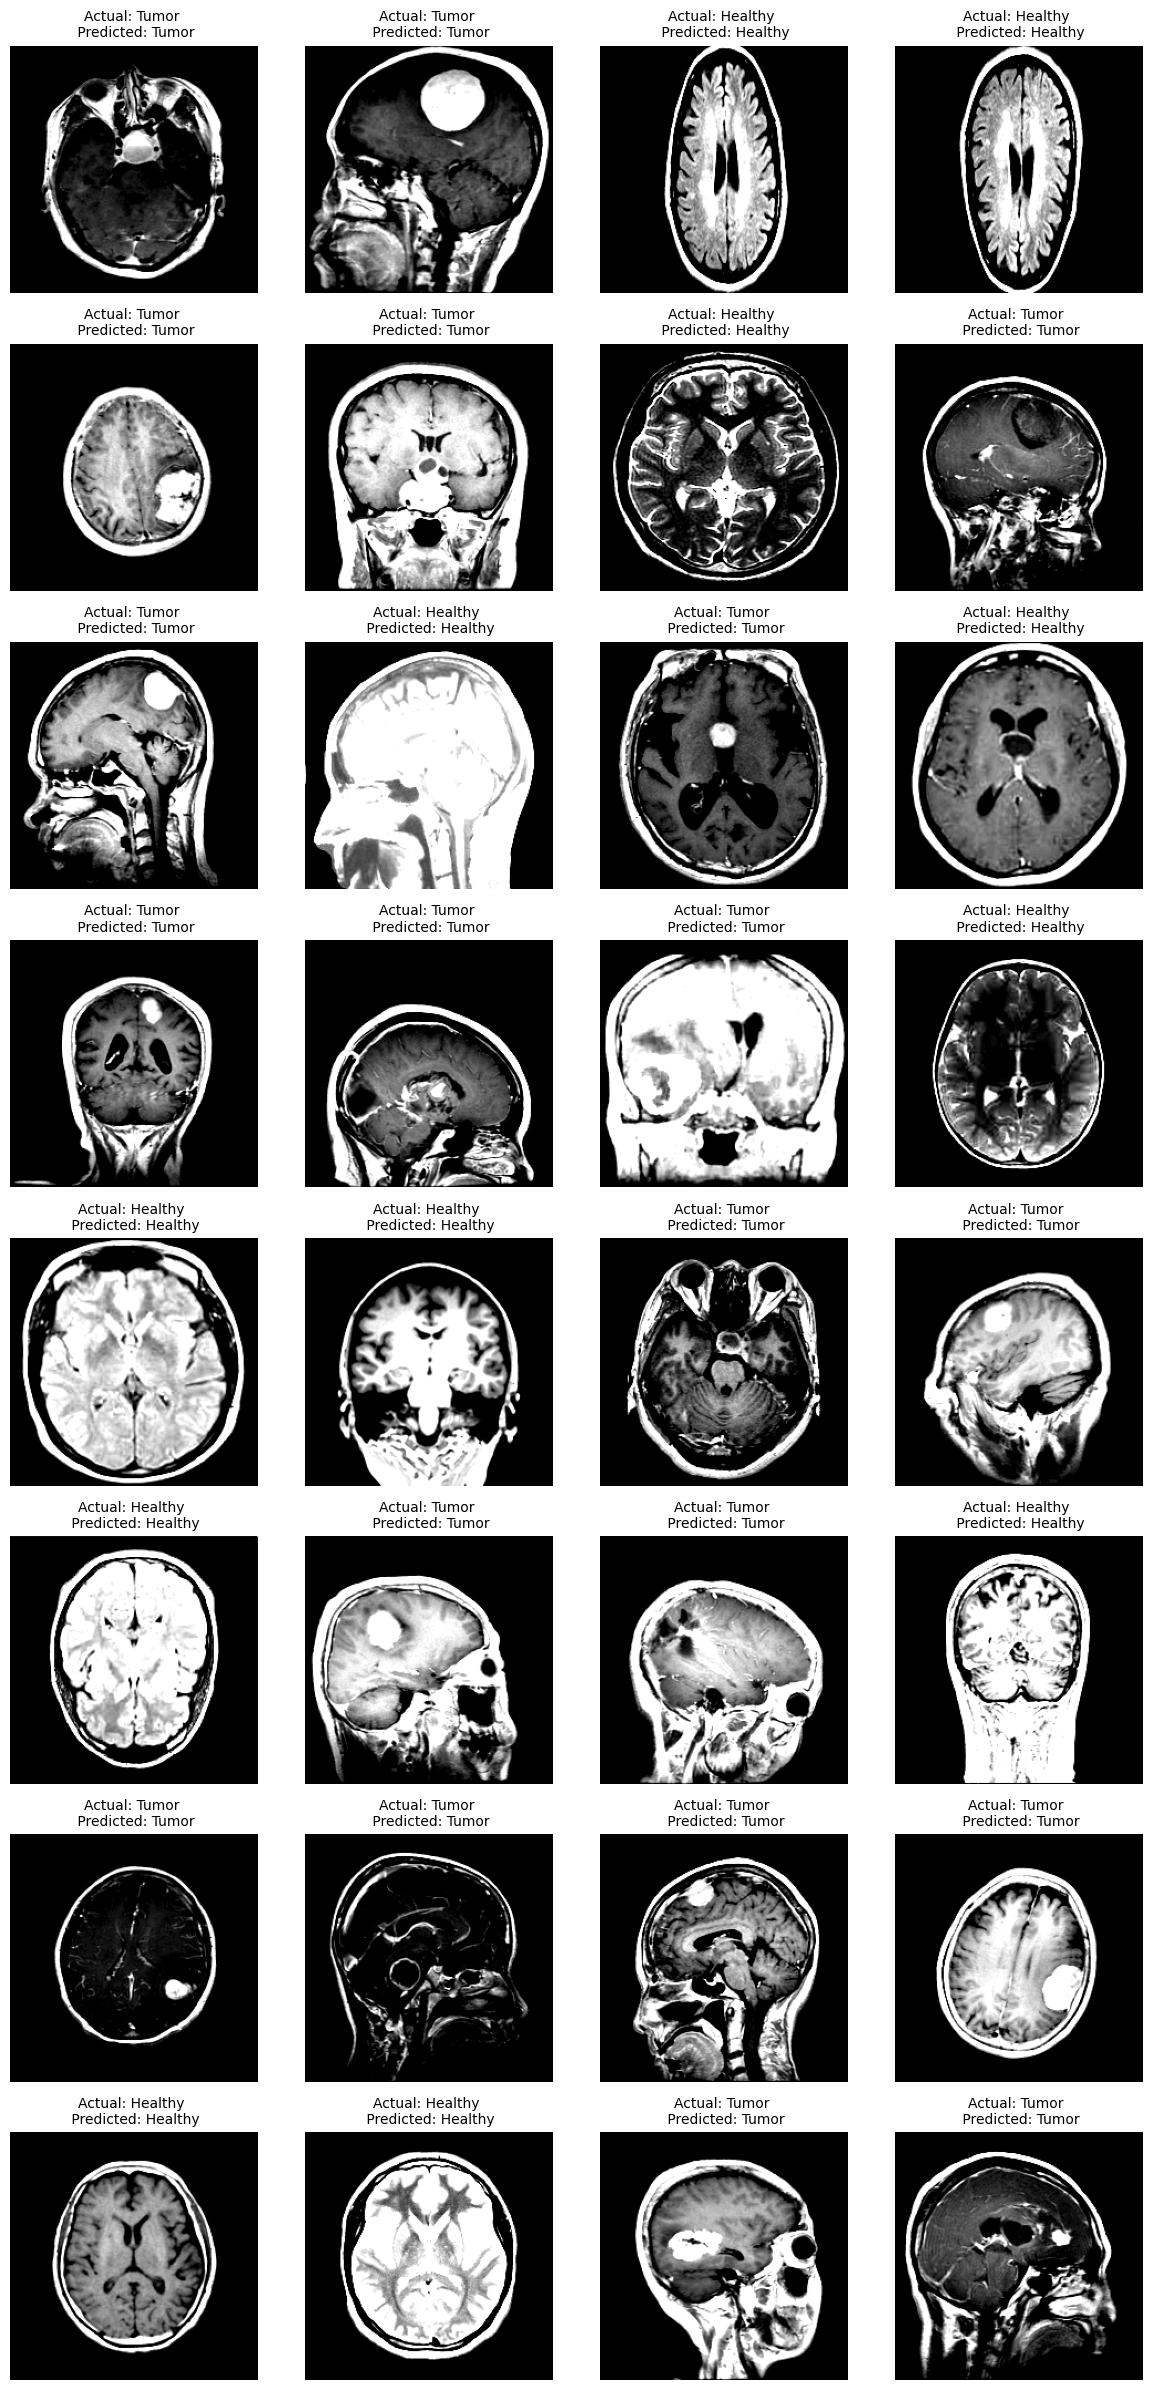

In [100]:
# Predicting some labels using our stored model
inputs, labels = next(iter(test_loader)) # Taking some data from test_data

inputs, labels = inputs.to(device), labels.to(device)

MRI_saved_model.eval()  # Changing the mode of our model to Evaluation model

output_logits = MRI_saved_model(inputs)
_,predicted_indices = torch.max(output_logits,1)

true_labels = [dataset.classes[label.item()] for label in labels]
predicted_labels = [dataset.classes[label.item()] for label in predicted_indices]

batch_size = len(inputs)
cols = 4
rows = (batch_size + cols -1) // cols

plt.figure(figsize = (12,rows * 3))
for idx in range(batch_size):
    plt.subplot(rows,cols,idx + 1)
    img = inputs[idx].cpu().permute(1,2,0).numpy()
    true_label = true_labels[idx]
    predicted_label = predicted_labels[idx]
    plt.imshow(img)
    plt.title(f"Actual: {true_label} \n Predicted: {predicted_label}", fontsize = 10)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [157]:
# Let's define a function which will take a input of image_path and return the image with results 

def MRI_Image_Tumor_Prediction(image_path,class_names,actual_label = ""):
    # Open the image
    image = Image.open(image_path)
    
    input_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension
    MRI_saved_model.eval()  # Changing the mode of our model to Evaluation model
    
    with torch.no_grad():
        output_logit = MRI_saved_model(input_tensor)
        _,predicted_idx = torch.max(output_logit,1)
    
    predicted_label = class_names[predicted_idx.item()]
    
    # Plot the image
    plt.imshow(image)
    plt.axis("off")
    title = f"Predicted: {predicted_label}"
    if actual_label != "":
        title += f"\nActual: {actual_label}"
    else:
        title += f"\nActual: Not Given"
    plt.title(title, fontsize=12, color="blue")
    plt.show()

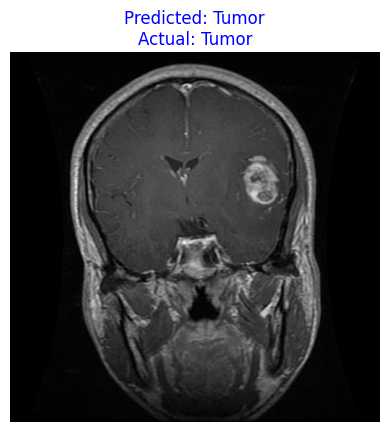

In [160]:
# Calling the stored function to predict the results
# Path to your image file
img_path_tumor = "C:/Users/harde/.cache/kagglehub/datasets/murtozalikhon/brain-tumor-multimodal-image-ct-and-mri/versions/1/Dataset/Brain Tumor MRI images/Tumor/glioma (50).jpg"
img_path_healthy = "C:/Users/harde/.cache/kagglehub/datasets/murtozalikhon/brain-tumor-multimodal-image-ct-and-mri/versions/1/Dataset/Brain Tumor MRI images/Healthy/mri_healthy (15).jpg"
class_names = ['Healthy','Tumor']
actual_label = class_names[1]
MRI_Image_Tumor_Prediction(img_path_tumor,class_names,actual_label)